### Algorytm generyczny:

In [34]:
import numpy as np
import random


def generate_chromosome(bounds):
    return [random.uniform(low, high) for low, high in bounds]

def evaluate(individual, goal_func, args=()):
    return goal_func(np.array(individual), *args)

def roulette_wheel_selection(results):
    fitnesses = [fit for fit, _ in results]
    min_fit = min(fitnesses)
    inverted_fitnesses = [1 / (fit - min_fit + 1e-6) for fit in fitnesses] 
    total = sum(inverted_fitnesses)
    pick = random.uniform(0, total)
    current = 0
    for i, inv_fit in enumerate(inverted_fitnesses):
        current += inv_fit
        if current > pick:
            return results[i][1]  
    return results[0][1]

# def better_crossover(p1, p2, alpha=0.5):
#     child = []
#     for g1, g2 in zip(p1, p2):
#         child.append(alpha * g1 + (1 - alpha) * g2)
#     return child

def better_crossover(p1, p2, pk=0.9, k=4):
    n = len(p1)
    if n == 0:
        return []
    if random.random() > pk or k <= 0 or n == 1:
        return p1[:]

    max_k = min(k, n - 1)
    cut_points = sorted(random.sample(range(1, n), max_k))
    cut_points.append(n)  

    child = []
    take_from_p1 = True
    last = 0
    for cp in cut_points:
        if take_from_p1:
            child.extend(p1[last:cp])
        else:
            child.extend(p2[last:cp])
        take_from_p1 = not take_from_p1
        last = cp

    return child

def mutate_m_point(chromosome, pm, bounds, m=2):
    n = len(chromosome)
    if random.random() > pm or n < 2:
        return chromosome

    m = min(m, n)
    mutation_indices = random.sample(range(n), m)

    if len(mutation_indices) % 2 == 1:
        mutation_indices = mutation_indices[:-1]

    for i in range(0, len(mutation_indices), 2):
        idx1 = mutation_indices[i]
        idx2 = mutation_indices[i + 1]
        chromosome[idx1], chromosome[idx2] = chromosome[idx2], chromosome[idx1]

    for idx in set(mutation_indices):
        low, high = bounds[idx]
        chromosome[idx] = max(low, min(high, chromosome[idx]))

    return chromosome

def mutate(chromosome, mutation_rate, bounds, sigma=0.1):
    for i in range(len(chromosome)):
        if random.random() < mutation_rate:
            low, high = bounds[i]
            scale = sigma * (high - low)
            chromosome[i] += random.gauss(0, scale)
            chromosome[i] = max(low, min(high, chromosome[i])) 
    return chromosome


def genetic_algorithm(goal_func, bounds, args=(), generations=100, pop_size=50, mutation_rate=0.1, best_rate=0.2):
    population = [generate_chromosome(bounds) for _ in range(pop_size)]
    best_chromosome = None
    best_fitness = float('inf')
    fitness_history = []
    print(f"BOUNDS: {bounds}")
    for gen in range(generations):
        fitnesses = [evaluate(individual, goal_func, args) for individual in population]
        results = list(zip(fitnesses, population))
        results.sort(key=lambda x: x[0])

        if results[0][0] < best_fitness:
            best_fitness = results[0][0]
            best_chromosome = results[0][1][:] 
        fitness_history.append(best_fitness)

        num_best = int(pop_size * best_rate)
        best_individuals = [ind[:] for fit, ind in results[:num_best]]

        new_population = best_individuals[:]

        while len(new_population) < pop_size:
            p1 = roulette_wheel_selection(results)
            p2 = roulette_wheel_selection(results)
            child = better_crossover(p1, p2)
            child = mutate(child, mutation_rate, bounds)
            # child = mutate_m_point(child, pm=mutation_rate, bounds=bounds, m=2)
            new_population.append(child)

        if (gen + 1) % 100 == 0 or gen == 0:
            print(f"Generacja {gen + 1}/{generations}: najlepszy wynik = {best_fitness:.6f}")
        
        population = new_population

    print(f"\nOptymalizacja GA zakończona!")
    print(f"Najlepszy wynik: {best_fitness:.6f}")
    
    return type('Result', (), {'x': np.array(best_chromosome), 'fun': best_fitness, 'nfev': generations * pop_size, 'nit': generations}), fitness_history

### ANFIS zoptymalizowany algorytmem genetycznym:

In [35]:
# -*- coding: utf-8 -*-
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids, FuzzyInputVariable_List_Trapezoids
from operators import productN
import numpy as np
#from helps_and_enhancers import *
import matplotlib.pyplot as plt
from ANFIS import ANFIS
import time
import copy
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

import numpy as np
from scipy.optimize import minimize, basinhopping
from scipy.stats import variation
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import permutations, combinations
import time
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from helps_and_enhancers import calculate_combinations, my_reshape
from operators import productN
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids

from goal_function_object import *

def productN(args, op):
    return np.prod(args, axis=0)
    

class ANFIS:
    
    def __init__(self, inputs, training_data: np.ndarray, expected_labels: np.ndarray, operator_function=productN, operator_init_value=0.5):
        self.input_list = inputs
        self.input_number = len(inputs)
        self.training_data = training_data
        self.expected_labels = expected_labels
        
        self.premises = []
        for i in range(self.input_number):
            self.premises.append(self.input_list[i].get())

        self.nodes_number = np.prod([inp.n_functions for inp in self.input_list])
        
        self.operator_function=operator_function
        
        #self.tsk = np.ones((self.nodes_number ,self.input_number+1))
        self.tsk = np.random.random((self.nodes_number ,self.input_number+1))
        
        self.op  = [operator_init_value]*self.nodes_number

        self.calculate_aids()

    #Wyswietlanie funkcji przynależnosci
    def show_inputs(self):
        plt.figure()
        for i in range(self.input_number):
            plt.subplot(self.input_number, 1, i+1)
            self.input_list[i].show()
            plt.legend()
        plt.show()

    def set_premises_parameters(self, fv):
        fv = np.array(fv).reshape(np.shape(self.premises))
        self.premises=fv
        for i in range(self.input_number):
            self.input_list[i].set(*fv[i])
             
    def calculate_aids(self):
        self.premises_combinations = np.array(calculate_combinations(self))[:,::-1]

    def output_to_labels(self, y_pred):
        rounded = np.round(y_pred.flatten()).astype(int)
        r_shape = np.shape(rounded)
        return np.max((np.min((rounded , np.ones(r_shape)),axis=0), np.zeros(r_shape)),axis=0)#clamp 0-1       
               
    def anfis_estimate_labels(self, fv, op, tsk) -> np.ndarray:

        data = self.training_data

        self.set_premises_parameters(fv)
        tsk=np.reshape(tsk,np.shape(self.tsk))
        memberships = [self.input_list[x].fuzzify(data[x]) for x in range(self.input_number)]
        
        #Wnioskowanie
        arguments = []
        for premises in self.premises_combinations:
            item = []
            for i in range(len(premises)):
                item.append(np.array(memberships[i])[:,premises[i]])
            arguments.append(   item  )

        arguments = np.transpose(arguments, (1,2,0))
        
        R=self.operator_function(arguments, op)
        
        #Normalizacja normalizacja poziomów aktywacji reguł
        Rsum = np.sum(R, axis=1, keepdims=True)

        Rnorm = R / Rsum
        Rnorm[(Rsum==0).flatten(),:] = 0
        # wylicz wartoci przesłanek dla każdej próbki
        
        dataXYZ1 = np.vstack((self.training_data,np.ones(len(self.training_data[0])))).T
        Q = np.dot(dataXYZ1, tsk.T) 
        
        # wyznacz wyniki wnioskowania dla każdej próbki
        result = (Q * Rnorm).sum(axis=1, keepdims=True)
    
        return result.T    
        
    def show_results(self, color=None):
        
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        
        if color is None:
            color = [[1,0,0] if cc else [0,1,0] for cc in self.expected_labels]

        result = self.anfis_estimate_labels(self.premises,self.op,self.tsk)
        
        #ax.scatter(np.array(self.training_data)[:,0], np.array(self.training_data)[:,1], result, c=rgb)
        ax.scatter(self.training_data[0], self.training_data[1], result, c=color)
        
        plt.show()
    
    def set_training_and_testing_data(self, training_data, expected_labels):
        self.training_data = training_data
        self.expected_labels = expected_labels
        
    def train(self, global_optimization: bool, learn_premises: bool, learn_operators: bool, learn_consequents: bool, 
              n_iter=100, bounds_premises=None, use_genetic_algorithm=False, ga_pop_size=50, ga_mutation_rate=0.1, ga_best_rate=0.2):
    
        x1 = [ item for sublist in self.premises for item in sublist ]
        x1 = np.array(x1).flatten()
        x2 = self.op
        x3 = self.tsk.flatten()
          
        if bounds_premises is None:
            bfv = [(0,4)]*len(x1)
        else:
            bfv = bounds_premises
        bop  = [(0.0,2.0)]*len(x2)
        btsk = [(0,2)]*len(x3)
        
        niter_success=100
            
        if learn_premises and learn_operators and learn_consequents:
            x0 = np.hstack((x1,x2,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop + btsk
            
            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_premises_operators_consequents,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = basinhopping(goal_premises_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
            
        elif learn_premises and learn_operators:
            x0 = np.hstack((x1,x2))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop

            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_premises_operators,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_premises_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]

        elif learn_premises and learn_consequents:
            x0 = np.hstack((x1,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv + btsk

            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_premises_consequents,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = basinhopping(goal_premises_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter)#, niter_success=niter_success)
            else:
                res = minimize(goal_premises_consequents, x0, method='SLSQP', bounds=bounds, args=self, tol=1e-6)

            self.set_premises_parameters(res.x[:self.end_x1]) ##zmiana funkcji
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))

        elif learn_operators and learn_consequents:
            x0 = np.hstack((x2,x3))
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop + btsk

            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_operators_consequents,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
        
        elif learn_premises:
            x0 = x1
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv

            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_premises,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_premises, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:].reshape(np.shape(self.premises)))

        elif learn_operators:
            x0 = x2
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop

            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_operators,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[:]
            
        elif learn_consequents:
            x0 = x3
            self.end_x1 = 0
            self.end_x2 = 0
            
            bounds = btsk

            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_consequents,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self), "tol":1e-03}
                res = basinhopping(goal_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.tsk=res.x[:].reshape(np.shape(self.tsk))
            
        else:
            print("Error")
            assert(0)
            
        print("Optymalizacja zakończona!")
        print("z blędem:  ", res.fun)
        print("Liczba ew: ", res.nfev)
        print("Liczba it: ", res.nit)

        if use_genetic_algorithm:
            return fitness_history
        else:
            return None


### Test algorytmu na tabliczce 3x3:

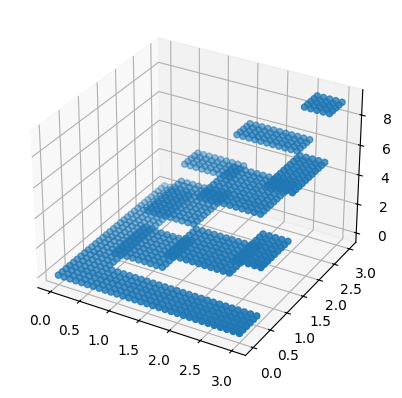


Parametry przed uczeniem:
Premises shape: (2, 3, 4)
Operators length: 9
TSK shape: (9, 3)
BOUNDS: [(0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 4), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2)]
Generacja 1/5000: najlepszy wynik = 922.676844


C:\Users\jasin\AppData\Local\Temp\ipykernel_5024\4014029555.py:103: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Generacja 100/5000: najlepszy wynik = 280.851584
Generacja 200/5000: najlepszy wynik = 239.280051
Generacja 300/5000: najlepszy wynik = 227.813283
Generacja 400/5000: najlepszy wynik = 224.952630
Generacja 500/5000: najlepszy wynik = 219.300244
Generacja 600/5000: najlepszy wynik = 214.661862
Generacja 700/5000: najlepszy wynik = 213.461619
Generacja 800/5000: najlepszy wynik = 212.509142
Generacja 900/5000: najlepszy wynik = 211.950173
Generacja 1000/5000: najlepszy wynik = 211.898133
Generacja 1100/5000: najlepszy wynik = 210.828353
Generacja 1200/5000: najlepszy wynik = 210.806742
Generacja 1300/5000: najlepszy wynik = 210.415683
Generacja 1400/5000: najlepszy wynik = 210.186598
Generacja 1500/5000: najlepszy wynik = 210.169521
Generacja 1600/5000: najlepszy wynik = 209.189491
Generacja 1700/5000: najlepszy wynik = 209.189491
Generacja 1800/5000: najlepszy wynik = 208.688323
Generacja 1900/5000: najlepszy wynik = 208.559919
Generacja 2000/5000: najlepszy wynik = 208.389355
Generacja

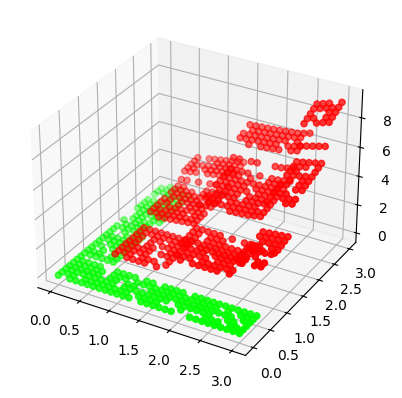


Czas uczenia: 42.06 s
MSE na zbiorze testowym: 0.054264

ZBIÓR TESTOWY:


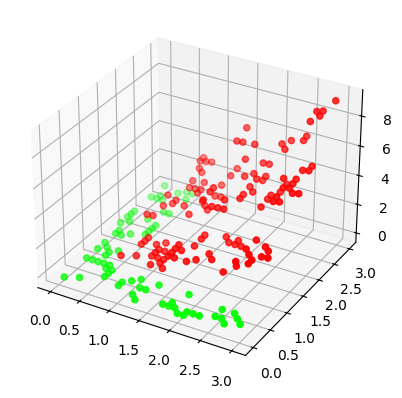

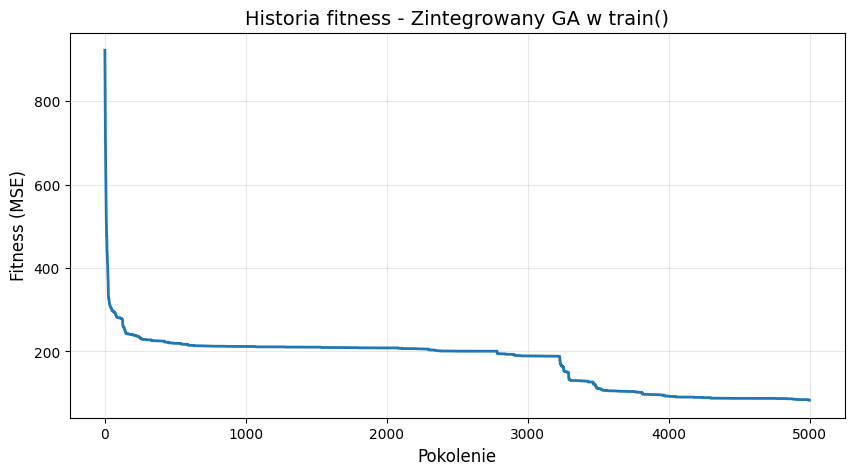

In [36]:
mf_list = [[0, 0, 0.125, 0.25], [0.125, 0.1875, 0.3125, 0.375],
                      [0.375, 0.4375, 0.5625, 0.625]]
labels = ["L", "M", "H"]

x = np.arange(0, 3.1, 0.1)
y = np.arange(0, 3.1, 0.1)
xx, yy = np.meshgrid(x, y)
    
dataX = xx.flatten()
dataY = yy.flatten()
dataXY = np.column_stack((dataX, dataY))
data_labels = np.round(dataX) * np.round(dataY)
    
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(dataX, dataY, data_labels)
plt.show()

varX = FuzzyInputVariable_List_Trapezoids(mf_list, "XAxis", labels)
varY = FuzzyInputVariable_List_Trapezoids(mf_list, "YAxis", labels)

X_train, X_test, y_train, y_test = train_test_split(
    dataXY, data_labels, test_size=0.2, random_state=42, stratify=data_labels
)

fis = ANFIS([varX, varY], X_train.T, y_train, operator_init_value=0.5)

print("\nParametry przed uczeniem:")
print(f"Premises shape: {np.shape(fis.premises)}")
print(f"Operators length: {len(fis.op)}")
print(f"TSK shape: {np.shape(fis.tsk)}")

start = time.time()

fitness_history = fis.train(
    global_optimization=True,
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=5000,                   
    use_genetic_algorithm=True,  
    ga_pop_size=30,             
    ga_mutation_rate=0.15,      
    ga_best_rate=0.2            
)

# OPTIMAL: popsize=30, mutation_rate=0.1, best_rate=0.2
# popsize = 30, mutation_rate = 0.08, best_rate = 0.25

elapsed = time.time() - start

print(f"\nParametry po uczeniu:")
print(f"Premises:\n{fis.premises}")
print(f"TSK:\n{fis.tsk}")

fis.training_data = X_train.T
fis.expected_labels = y_train
y_pred_train = fis.anfis_estimate_labels(fis.premises, fis.op, fis.tsk)
mse_train = np.mean((y_train - y_pred_train.flatten())**2)
print(f"\nMSE na zbiorze treningowym: {mse_train:.6f}")

print("\nZBIÓR TRENINGOWY:")
fis.show_results()

fis.training_data = X_test.T
fis.expected_labels = y_test
y_pred_int = fis.anfis_estimate_labels(fis.premises, fis.op, fis.tsk)
mse_int = np.mean((y_test - y_pred_int.flatten())**2)

print(f"\nCzas uczenia: {elapsed:.2f} s")
print(f"MSE na zbiorze testowym: {mse_int:.6f}")

print("\nZBIÓR TESTOWY:")
fis.show_results()

if fitness_history is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(fitness_history, linewidth=2)
    plt.xlabel('Pokolenie', fontsize=12)
    plt.ylabel('Fitness (MSE)', fontsize=12)
    plt.title('Historia fitness - Zintegrowany GA w train()', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()
